**Data Loading and Initial Checks**

This section loads the A/B test dataset and checks its structure, missing values, duplicate rows and available test groups.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

os.listdir('/content')

['.config',
 'conversion_rate_by_variant.png',
 'daily_conversion_trend_clean.png',
 'ab_test_data.csv',
 'sample_data']

In [ ]:
df = pd.read_csv('ab_test_data.csv')
df

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0
...,...,...,...,...
19993,6763ae9a-515c-473e-af00-0d9c4f6a5bc7,2023-07-06 03:27:37.041104,b,0
19994,ac5600f2-4d16-4503-b115-f1a96728b6d1,2023-07-03 04:20:48.572143,a,0
19995,5a8b2630-209b-4d83-b47f-0f3d9dd568a8,2023-07-23 16:23:49.211910,b,1
19996,b572d68b-26ac-432b-9f88-83e0fdee4ca1,2023-07-03 18:26:20.880675,b,0


In [ ]:
df.info()
df.shape
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


,0
user_id,0
timestamp,0
test_group,0
conversion,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['test_group'].unique()

array(['a', 'b'], dtype=object)

**Conversion Summary by Test Group**

This section calculates users, conversions and conversion rate for each test group.

In [ ]:
# calculate users, conversions and conversion rate by test group
summary = df.groupby('test_group').agg(
    users=('user_id', 'nunique'),
    conversions=('conversion', 'sum'),
    conversion_rate=('conversion', 'mean')
).reset_index()

# convert conversion rate to percentage for easier interpretation
summary['conversion_rate'] = (summary['conversion_rate'] * 100).round(2)

summary

,test_group,users,conversions,conversion_rate
0,a,10013,611,6.1
1,b,9985,889,8.9


**Test Period**

This section converts the timestamp column to datetime format and calculates the test start date, end date and duration in calendar days.

In [ ]:
# convert timestamp from text format to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# calculate the test start date and end date
start_date = df['timestamp'].dt.date.min()
end_date = df['timestamp'].dt.date.max()

start_date, end_date

(datetime.date(2023, 7, 3), datetime.date(2023, 7, 25))

In [ ]:
# calculate test duration in calendar days
duration = (end_date - start_date).days + 1

duration

23

**Statistical Significance Testing**

This section tests whether the difference in conversion rates between Control A and Variant B is statistically significant.

**Hypotheses**

- **H0 (null hypothesis):** there is no statistically significant difference in conversion rates between Control A and Variant B.

- **H1 (alternative hypothesis):** there is a statistically significant difference in conversion rates between Control A and Variant B.

In [ ]:
# prepare conversion data for Control A and Variant B
conv_A = df[df['test_group'] == 'a']['conversion']
conv_B = df[df['test_group'] == 'b']['conversion']

# run an independent two-sample t-test
stat, p_value = stats.ttest_ind(conv_A, conv_B)

stat, p_value

(np.float64(-7.5299531387344185), np.float64(5.291057638517877e-14))

In [ ]:
# Set the significance level
alpha = 0.05

# Interpret the t-test result
if p_value < alpha:
    print('Reject H0: the difference between groups is statistically significant.')
else:
    print('Fail to reject H0: there is not enough evidence that the groups differ.')

Reject H0: the difference between groups is statistically significant.


**Additional Check: Permutation Test**

In [ ]:
# run a permutation test as an additional non-parametric check
perm_result = stats.permutation_test(
    (conv_A, conv_B),
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    alternative='two-sided',
    random_state=42
)

perm_result.statistic, perm_result.pvalue

(np.float64(-0.028012877200550658), np.float64(0.0002))

In [ ]:
# interpret the permutation test result
if perm_result.pvalue < alpha:
    print('Reject H0: the difference between groups is statistically significant.')
else:
    print('Fail to reject H0: there is not enough evidence that the groups differ.')

Reject H0: the difference between groups is statistically significant.


Both the t-test and the permutation test returned very small p-values below 0.05.

This means that the observed difference in conversion rates is unlikely to be explained by random variation alone.

Therefore, we reject the null hypothesis and conclude that Variant B achieved a statistically significant improvement in conversion rate compared with Control A.

**Conversion Rate Visualization**

This chart compares the conversion rate between Control A and Variant B using 95% confidence intervals.

In [ ]:
#sns.barplot?
#sns.set_style?
#plt.figure?
#sns.lineplot?

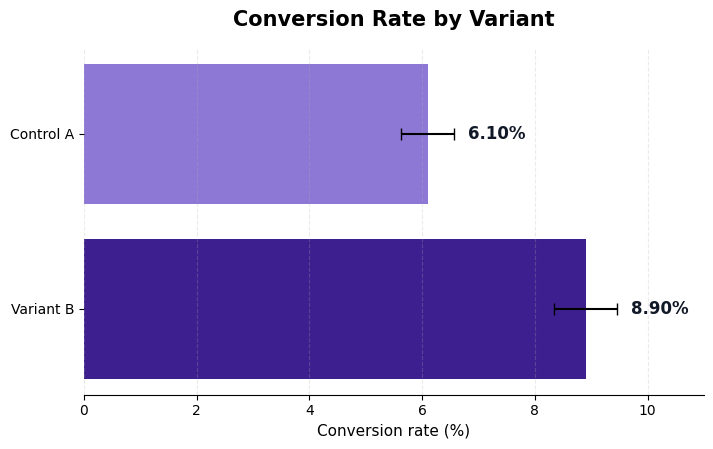

In [ ]:
# prepare summary data for the conversion rate chart
chart_data = summary.copy()

# rename test groups for clearer chart labels
chart_data['variant'] = chart_data['test_group'].map({
    'a': 'Control A',
    'b': 'Variant B'
})

# convert conversion rate from percentage to proportion for confidence interval calculation
chart_data['conversion_rate_prop'] = chart_data['conversion_rate'] / 100

# calculate standard error for each conversion rate
chart_data['standard_error'] = np.sqrt(
    chart_data['conversion_rate_prop'] * (1 - chart_data['conversion_rate_prop']) / chart_data['users']
)

# calculate 95% confidence interval in percentage points
chart_data['ci_95'] = 1.96 * chart_data['standard_error'] * 100

# set chart colors to match the presentation style
colors = ['#8E78D6', '#3E1F8F']

# create the horizontal bar chart
plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    chart_data['variant'],
    chart_data['conversion_rate'],
    xerr=chart_data['ci_95'],
    color=colors,
    edgecolor='none',
    capsize=4
)

# add value labels after the confidence interval line
for bar, value, ci in zip(bars, chart_data['conversion_rate'], chart_data['ci_95']):
    plt.text(
        value + ci + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.2f}%',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='#111827'
    )

# format chart title and axes
plt.title('Conversion Rate by Variant', fontsize=15, fontweight='bold', pad=16)
plt.xlabel('Conversion rate (%)', fontsize=11)
plt.ylabel('')

# set x-axis limits and grid
plt.xlim(0, 11)
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.gca().invert_yaxis()

# remove unnecessary chart borders
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

# save the chart as a high-resolution PNG file
plt.savefig('conversion_rate_by_variant.png', dpi=300, bbox_inches='tight')

plt.show()

**Daily Conversion Trend**

This chart shows how the daily conversion rate changed over time for Control A and Variant B.

In [ ]:
# create a separate date column from timestamp
df['date'] = df['timestamp'].dt.date

# calculate daily conversion rate by date and test group
daily_cr = df.groupby(['date', 'test_group'])['conversion'].mean().reset_index()

daily_cr

,date,test_group,conversion
0,2023-07-03,a,0.050971
1,2023-07-03,b,0.087640
2,2023-07-04,a,0.065022
3,2023-07-04,b,0.081858
4,2023-07-05,a,0.064220
5,2023-07-05,b,0.083151
6,2023-07-06,a,0.054705
7,2023-07-06,b,0.095918
8,2023-07-07,a,0.075472
9,2023-07-07,b,0.075949


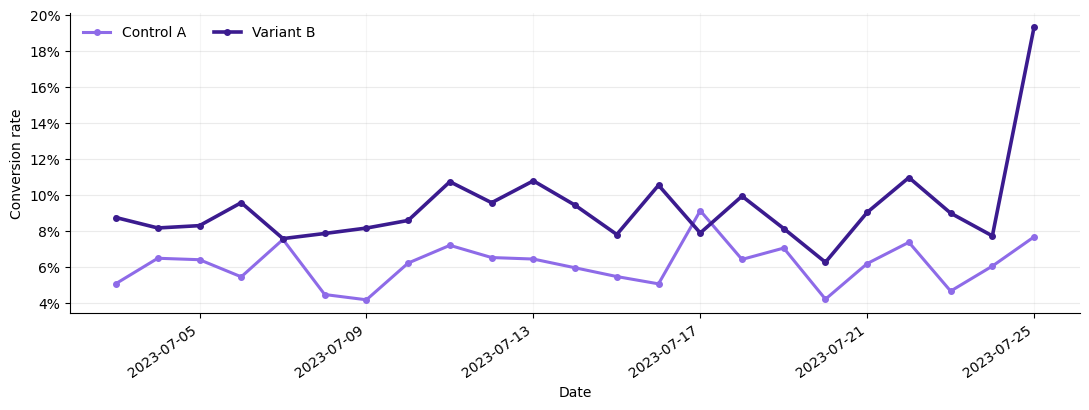

In [ ]:
# reshape the table for plotting:
# rows = dates, columns = test groups, values = daily conversion rate
daily_pivot = daily_cr.pivot(
    index='date',
    columns='test_group',
    values='conversion'
)

# create a compact line chart for the presentation
plt.figure(figsize=(11, 4.2))

# plot Control A conversion trend
plt.plot(
    daily_pivot.index,
    daily_pivot['a'],
    marker='o',
    linewidth=2.2,
    markersize=4,
    color='#8E6BE8',
    label='Control A'
)

# plot Variant B conversion trend
plt.plot(
    daily_pivot.index,
    daily_pivot['b'],
    marker='o',
    linewidth=2.6,
    markersize=4,
    color='#3B1B8F',
    label='Variant B'
)

# add axis labels
plt.ylabel('Conversion rate')
plt.xlabel('Date')

# format Y-axis as percentages
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)

# add a light grid to improve readability
plt.grid(axis='y', alpha=0.25)
plt.grid(axis='x', alpha=0.12)

# remove unnecessary chart borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# rotate dates for better readability
plt.xticks(rotation=35, ha='right')

# add a clean legend
plt.legend(
    loc='upper left',
    frameon=False,
    ncol=2
)

# Make the layout compact
plt.tight_layout()

# save the chart as a high-resolution PNG file
plt.savefig('daily_conversion_trend_clean.png', dpi=300, bbox_inches='tight')


plt.show()

In [ ]:
from google.colab import files

files.download('daily_conversion_trend_clean.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Variant B had a higher daily conversion rate than Control A during most of the test period.  
Daily results fluctuated from day to day, but the overall trend supports the main result: Variant B performed better on subscription conversion.